In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_contacts_kinematics_over_time.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_contacts_kinematics_over_time.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_contacts_kinematics_over_time.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_contacts_kinematics_over_time.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


df['heading_angle_change'] = (
    df
    .sort_values(['Condition', 'file', 'interaction_number', 'track_id', 'frame'])
    .groupby(['file', 'Condition', 'interaction_number', 'track_id'])['heading_angle']
    .diff()
    .abs() )


df['interaction_group'] = np.where(df['interaction_number'] == 1, 'first', 'other')


si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/1483801630.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=interactions_per_file, x='Condition', y='number_of_interactions', ci='sd')


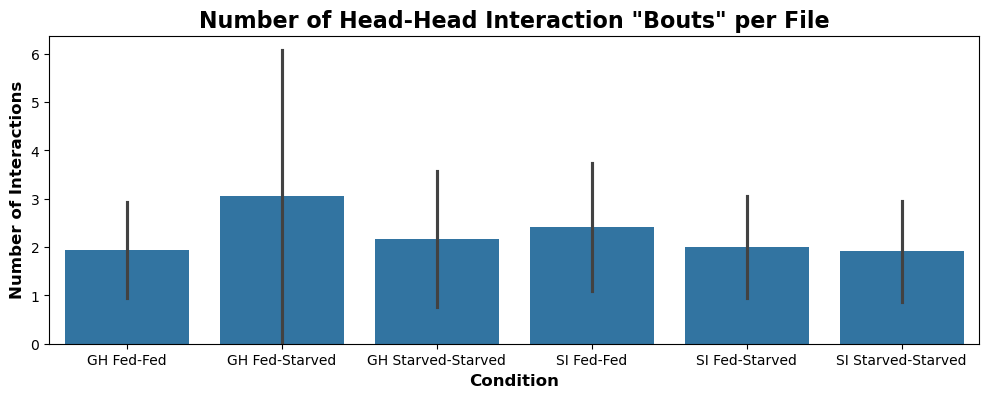

In [11]:
interactions_per_file = (
    df.groupby(['Condition', 'file'])['interaction_number']
      .max()
      .reset_index(name='number_of_interactions')
)


plt.figure(figsize = (12, 4))

sns.barplot(data=interactions_per_file, x='Condition', y='number_of_interactions', ci='sd')

plt.xlabel('Condition', fontsize=12, fontweight='bold')
plt.ylabel('Number of Interactions', fontsize=12, fontweight='bold')
plt.title('Number of Head-Head Interaction "Bouts" per File', fontsize=16, fontweight='bold')
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/3761283361.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


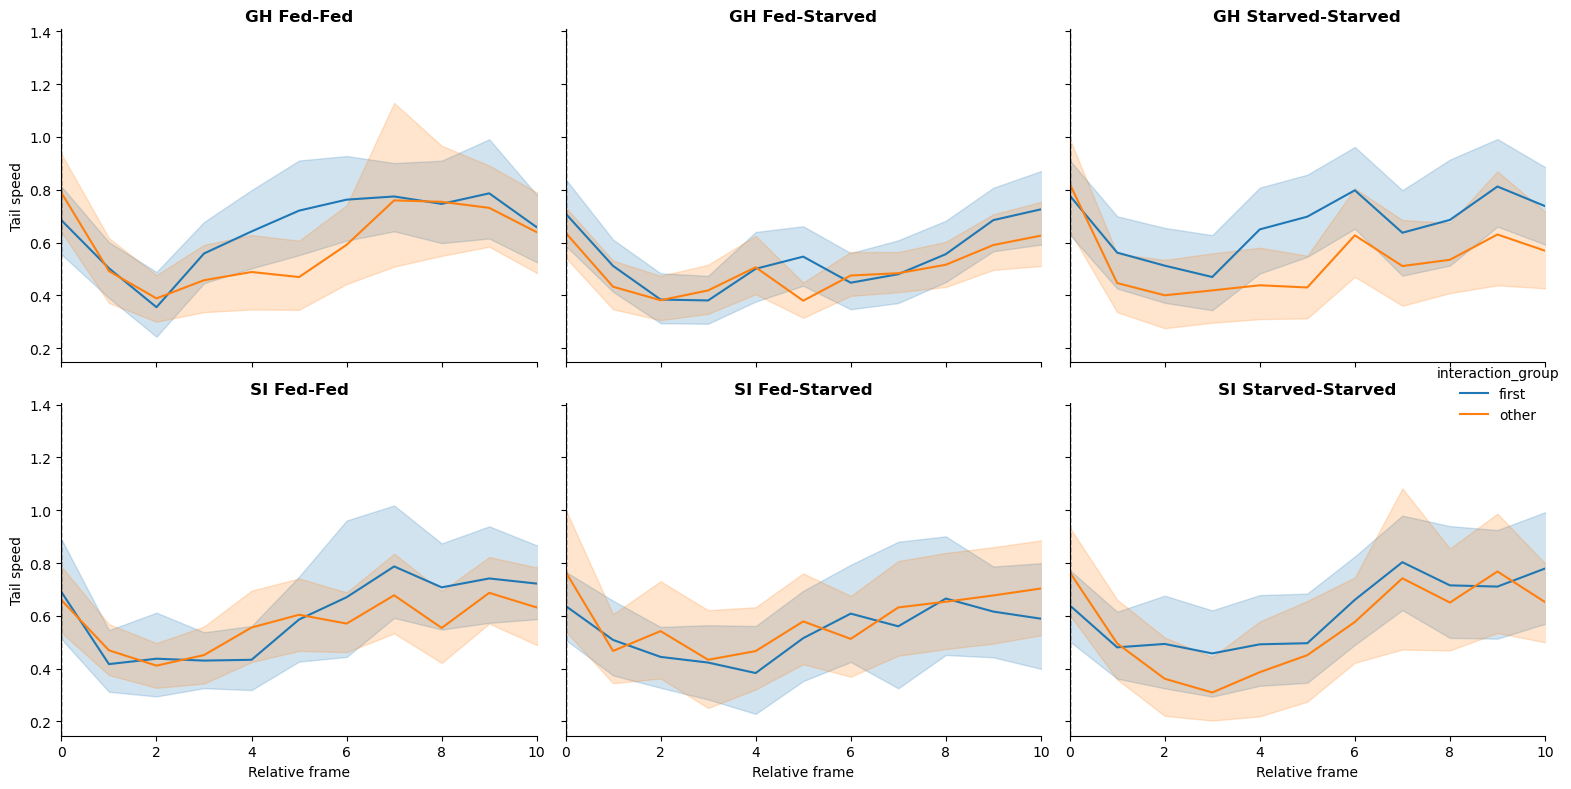

In [12]:
g = sns.relplot(
    data=df,
    x='rel_frame',
    y='speed_tail',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set(xlim=(0, 10))
g.set_axis_labels('Relative frame', 'Tail speed')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/3957377104.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


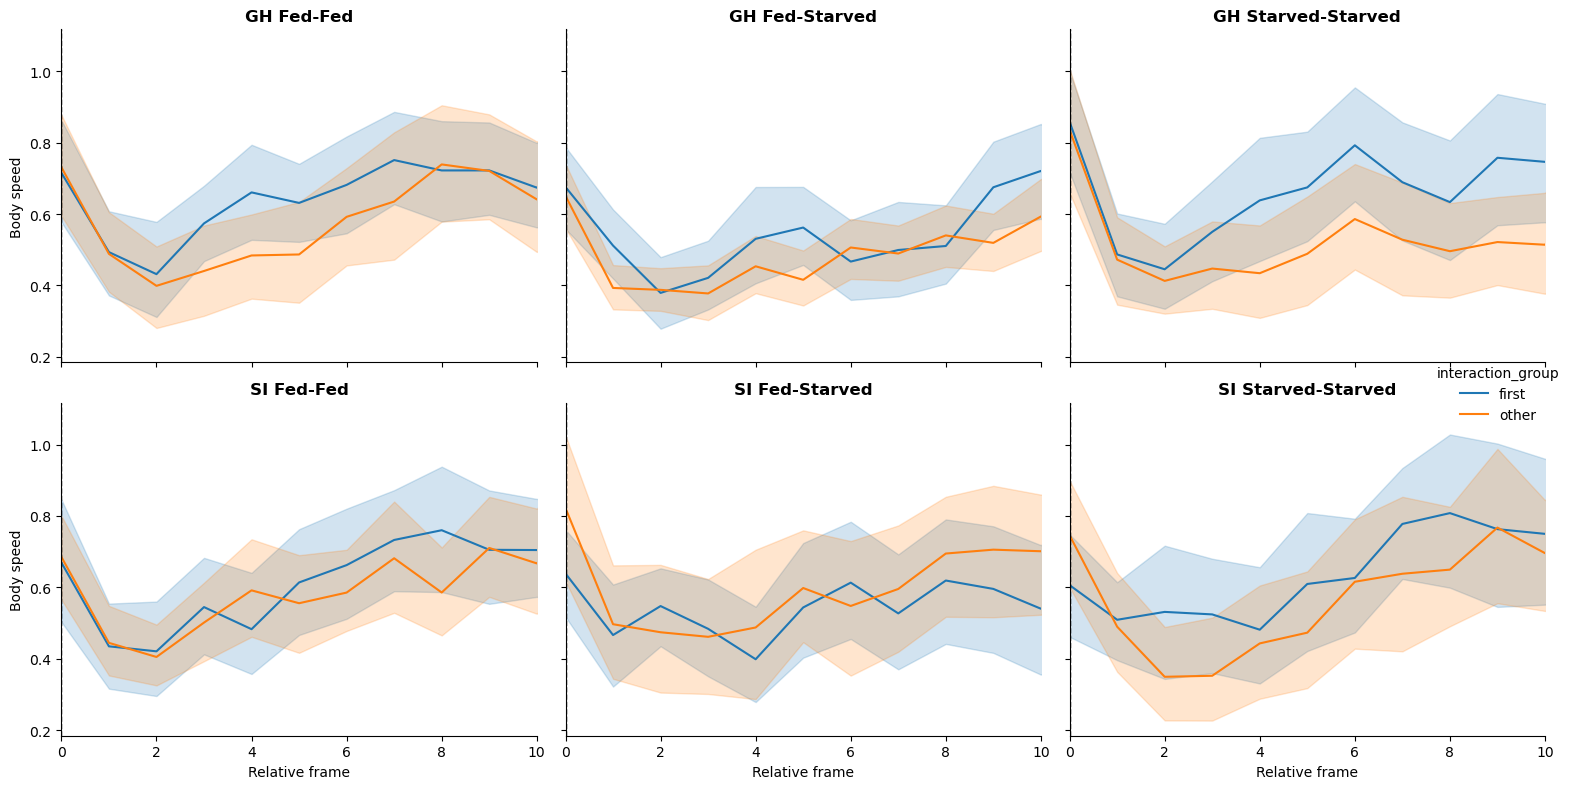

In [13]:
g = sns.relplot(
    data=df,
    x='rel_frame',
    y='speed_body',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set(xlim=(0, 10))
g.set_axis_labels('Relative frame', 'Body speed')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/944781152.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


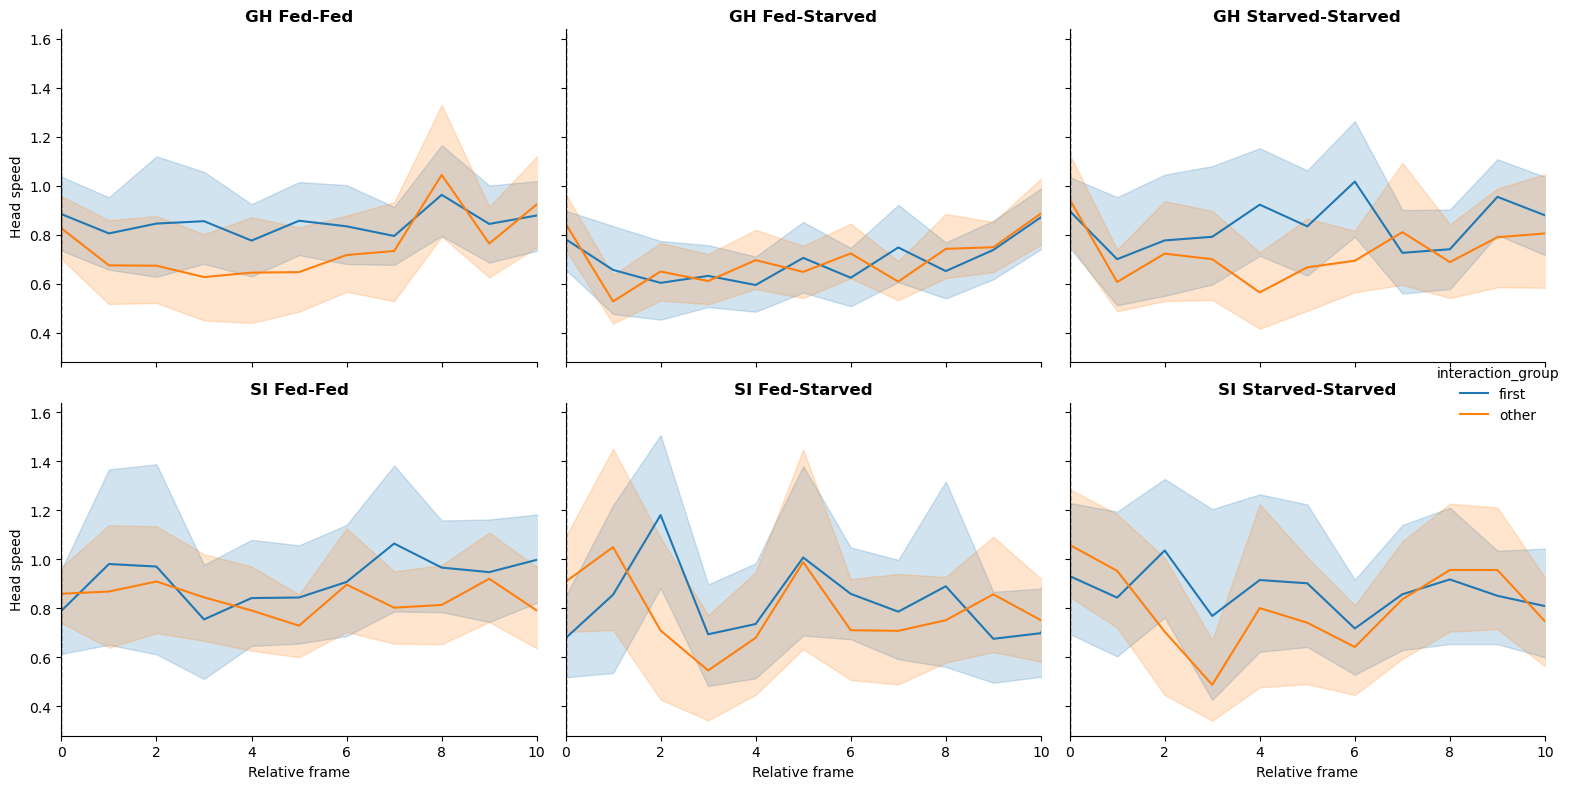

In [14]:
g = sns.relplot(
    data=df,
    x='rel_frame',
    y='speed_head',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set(xlim=(0, 10))
g.set_axis_labels('Relative frame', 'Head speed')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

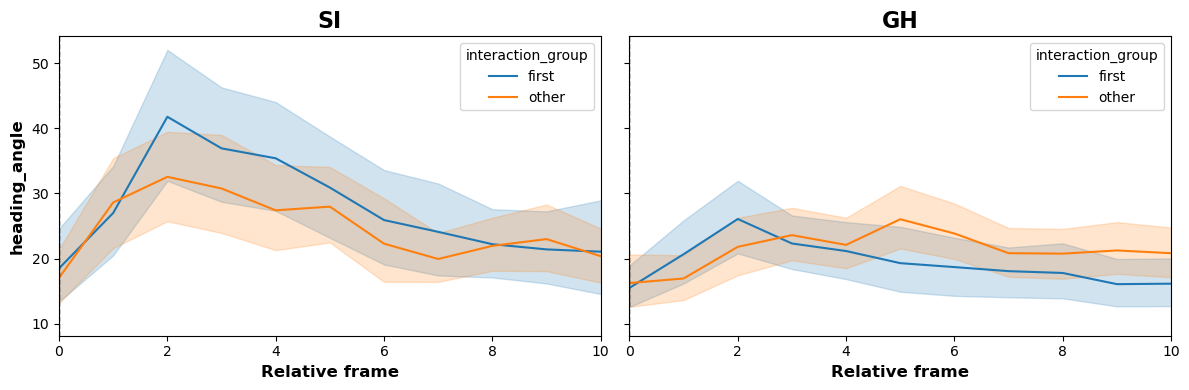

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='rel_frame',
    y='heading_angle',
    hue='interaction_group',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_xlim(0,10)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Relative frame', fontsize=12, fontweight='bold')
axes[0].set_ylabel('heading_angle', fontsize=12, fontweight='bold')
axes[0].set_title('SI', fontsize=16, fontweight='bold')

# GH
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='heading_angle',
    hue='interaction_group',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_xlim(0,10)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Relative frame', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_title('GH', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/63686151.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


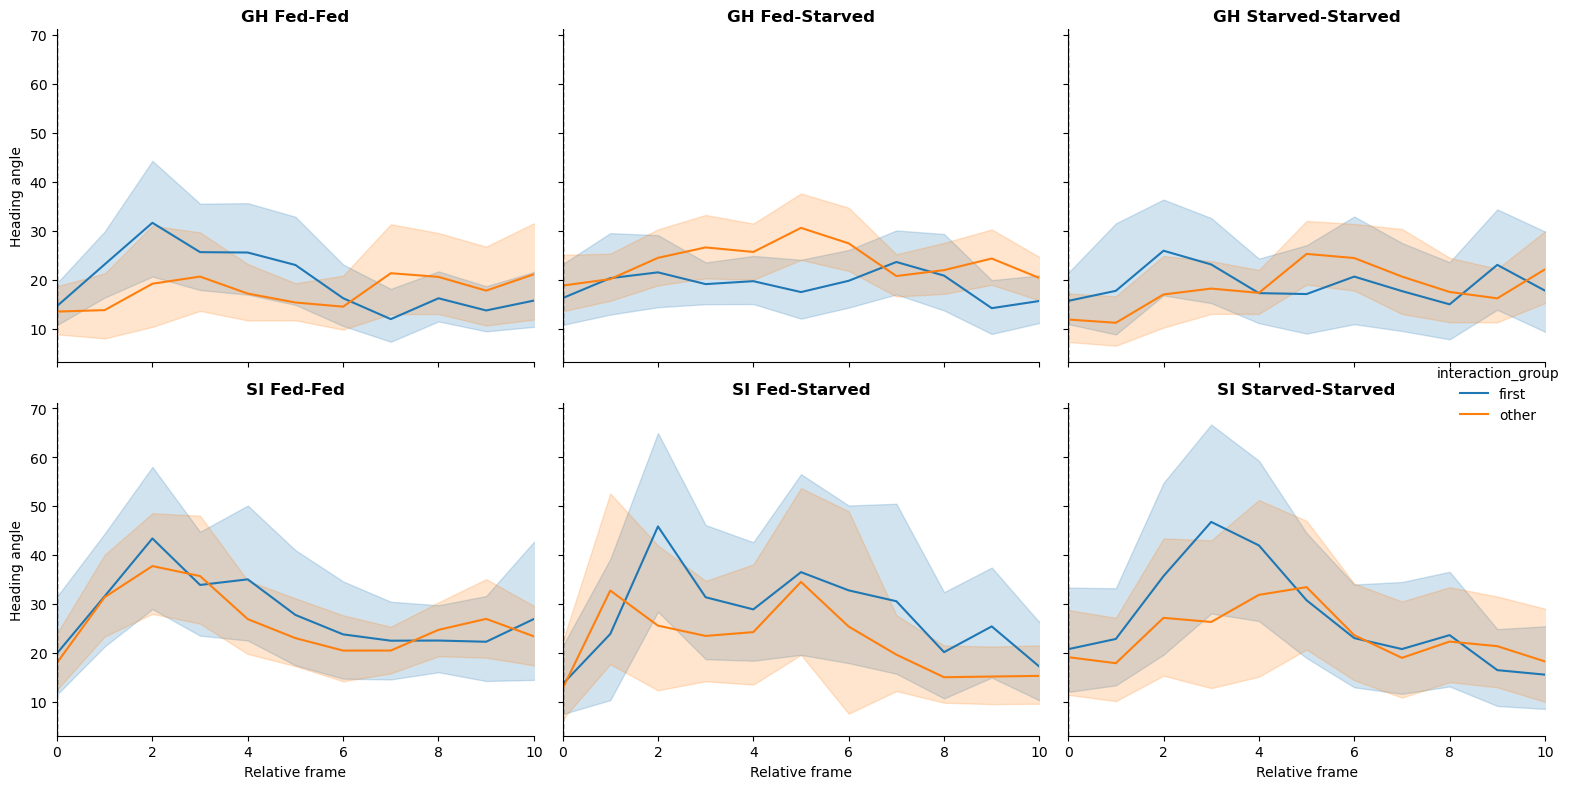

In [16]:
g = sns.relplot(
    data=df,
    x='rel_frame',
    y='heading_angle',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set(xlim=(0, 10))
g.set_axis_labels('Relative frame', 'Heading angle')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/2844837524.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


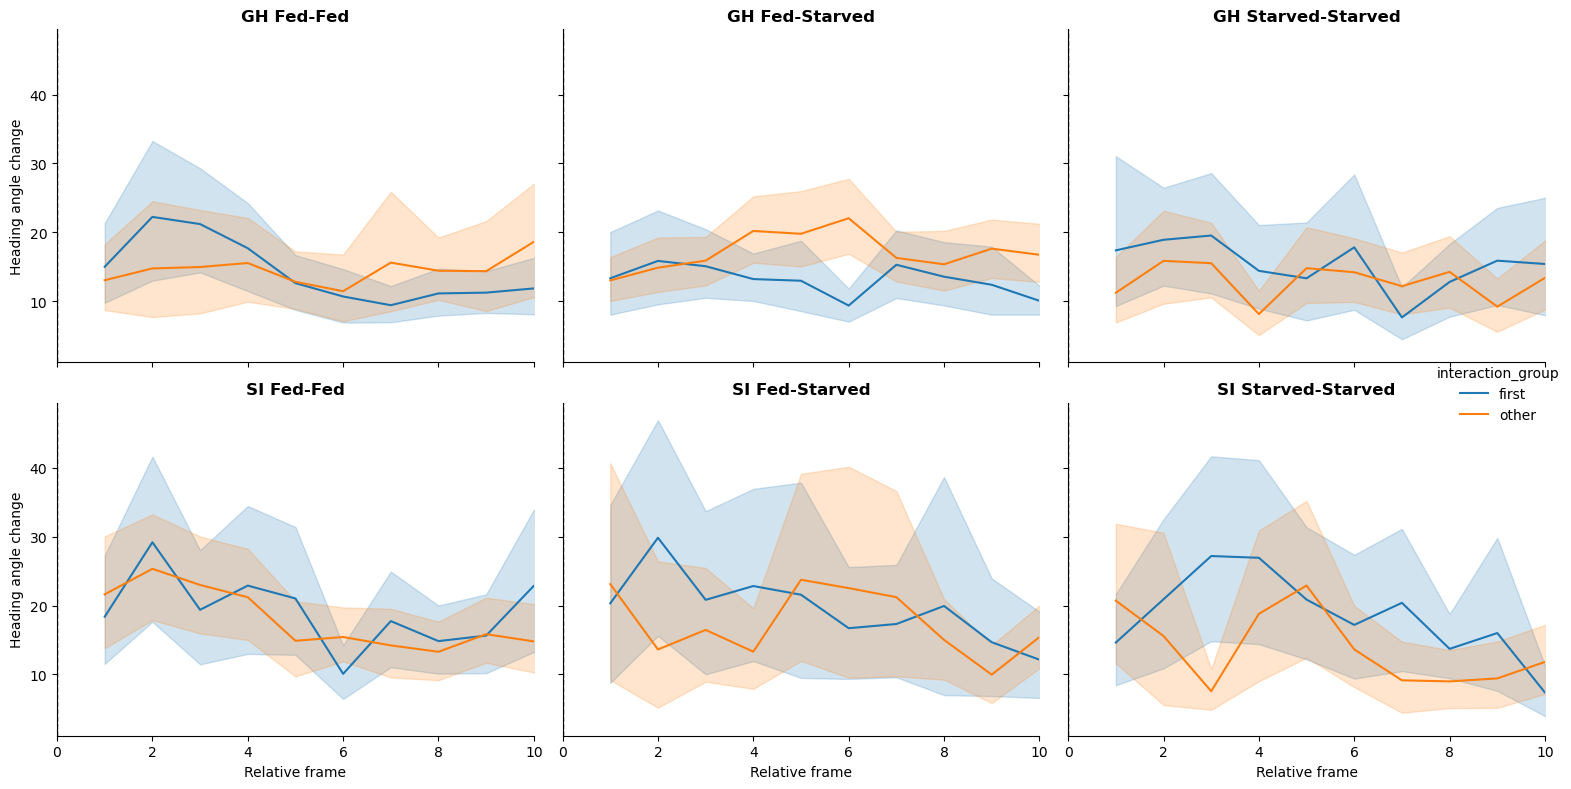

In [17]:
g = sns.relplot(
    data=df,
    x='rel_frame',
    y='heading_angle_change',
    hue='interaction_group',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set(xlim=(0, 10))
g.set_axis_labels('Relative frame', 'Heading angle change')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_92967/2776731092.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


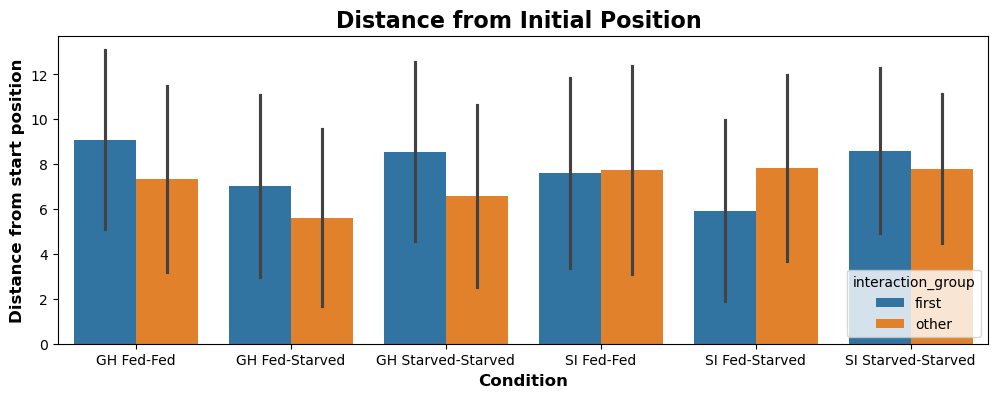

In [18]:
distance_covered = df[df['rel_frame'] == 15].copy()

plt.figure(figsize = (12, 4))

sns.barplot(
    data=distance_covered,
    x='Condition',
    y='dist_from_start',
    hue='interaction_group',
    ci='sd'
)
plt.xlabel('Condition', fontsize=12, fontweight='bold')
plt.ylabel('Distance from start position', fontsize=12, fontweight='bold')
plt.title('Distance from Initial Position ', fontsize=16, fontweight='bold') 


plt.show()
